# CO543: Image Processing - Lab 4

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(312.5), np.float64(160.5), np.float64(-0.5))

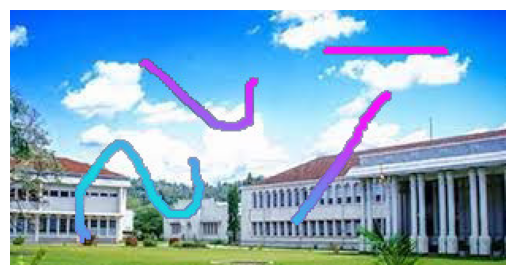

In [2]:
#Load Image

img = cv2.imread("Efac.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')

(np.float64(-0.5), np.float64(312.5), np.float64(160.5), np.float64(-0.5))

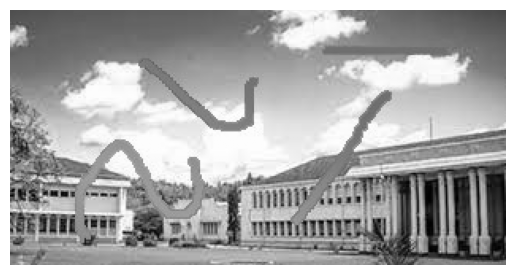

In [3]:
#Convert to GrayScale

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.axis('off')

# Task 1 — Threshold for Foreground/Background Separation

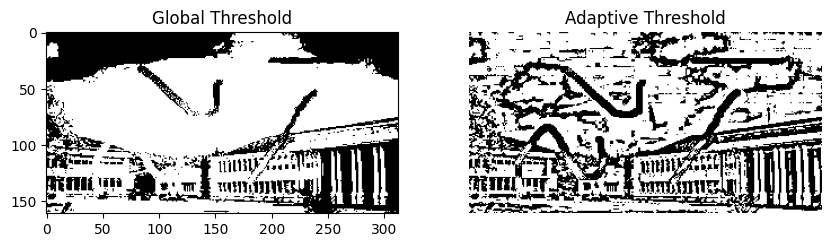

In [12]:
# Global Threshold
_, global_thr = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Adaptive Threshold
adaptive_thr = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11, 2
)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1), plt.imshow(global_thr, cmap='gray'), plt.title("Global Threshold")
plt.subplot(1,2,2), plt.imshow(adaptive_thr, cmap='gray'), plt.title("Adaptive Threshold")
plt.axis('off')
plt.show()

**Why uneven lighting or textured surfaces break naive thresholding?**

Global thresholding uses one fixed intensity value for the entire image. When lighting is uneven or the surface is textured, the same object may appear with different brightness levels. This causes incorrect separation of foreground and background. Adaptive thresholding works better because it computes local thresholds based on neighboring pixels.



---


**More to think: Is segmentation purely by intensity reliable outdoors?**

No. Outdoor scenes have shadows, reflections, and varying illumination. Objects with different meanings may have similar intensities, while the same object may appear with different intensities. Therefore, segmentation using intensity alone is unreliable in outdoor environments.

# Task 2 — K-Means Pixel Clustering

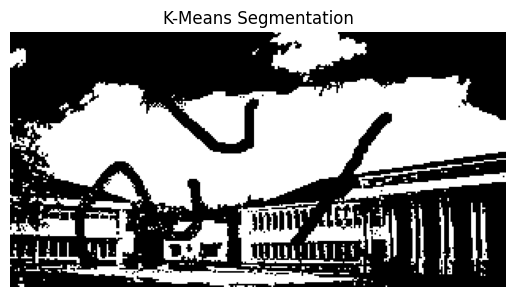

In [13]:
Z = gray.reshape((-1,1)).astype(np.float32)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
_, labels, centers = cv2.kmeans(Z, 2, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

segmented = centers[labels.flatten()].reshape(gray.shape)

plt.imshow(segmented, cmap='gray')
plt.title("K-Means Segmentation")
plt.axis('off')
plt.show()

**How color/intensity grouping supports object separation without semantic understanding**

K-means clusters pixels based on similarity in intensity values. It groups visually similar regions together without knowing what the objects are. This allows separation of scribbles and background purely using pixel statistics rather than understanding image content.


---


**More to think: When can two different objects fall into one cluster?**

Two different objects can fall into the same cluster when they have similar intensity or color values. For example, a dark wall and black scribbles may be grouped together even though they represent different objects.

# Task 3 — Edge Map for Structure Protection

(np.float64(-0.5), np.float64(312.5), np.float64(160.5), np.float64(-0.5))

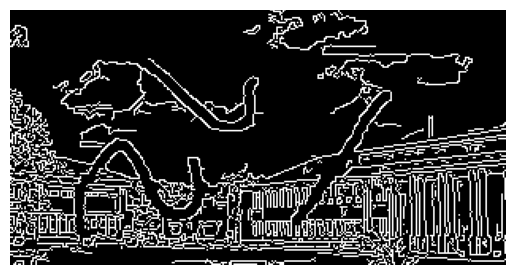

In [9]:
#Canny Edge Detection

edges = cv2.Canny(gray, 80, 160)

plt.imshow(edges, cmap='gray')
plt.axis('off')

**Discuss which edges represent true scene structure and scribble strokes**

Strong, continuous edges usually represent real scene structures such as walls, edges of buildings, or boundaries. Scribble strokes often produce thin, irregular, and less consistent edges.


---



**More to think:
Do scribbles always have different edge patterns than architecture?**

No. Thick or straight scribbles may produce edges similar to architectural lines. Therefore, edge detection alone cannot perfectly distinguish scribbles from real structures.

# Task 4 — Mask and Inpaint Damaged Regions

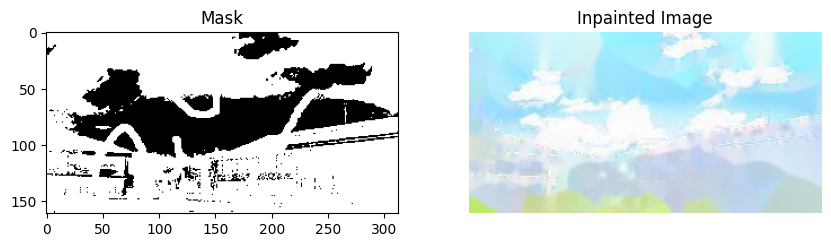

In [14]:
_, mask = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
inpainted = cv2.inpaint(img, mask, 3, cv2.INPAINT_TELEA)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1), plt.imshow(mask, cmap='gray'), plt.title("Mask")
plt.subplot(1,2,2), plt.imshow(inpainted), plt.title("Inpainted Image")
plt.axis('off')
plt.show()

**Reflect on realism: does the fill blend, or does the restored area look artificial?**

In smooth regions, the inpainted areas blend well with the surroundings. In regions with complex textures or patterns, the restored areas may look artificial due to incorrect texture reconstruction.


---


**More to think: How does inpainting hallucinate incorrect content on complex textures?**

Inpainting estimates missing pixels using surrounding information. When textures are complex, there is insufficient context to reconstruct details accurately, causing the algorithm to generate unrealistic or incorrect patterns.

# Final Reflection
**Describe how segmentation helps preparation for inpainting and why edge protection is crucial in restoration tasks**

Segmentation plays a crucial role in identifying damaged regions before restoration. Thresholding and clustering help isolate unwanted content, while edge detection preserves important structural details. Inpainting can effectively restore smooth areas but may introduce artifacts when dealing with complex textures, highlighting the importance of accurate segmentation and edge protection.